# Paper Figure 4 — partial displacement interpolation

The component coupling is solved once per `(lambda, epsilon)` row and reused
for all five interpolation times. Coupling weights are neither thresholded nor
renormalized, so each density integrates to the partial mass `Z_lambda`.


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from pgot import set_reproducible

set_reproducible()
OUTPUT_DIR = Path("outputs")
METADATA_DIR = Path("metadata")
OUTPUT_DIR.mkdir(exist_ok=True)
METADATA_DIR.mkdir(exist_ok=True)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from pgot import (
    FIGURE_PARAMETERS,
    entropic_partial_coupling,
    entropic_partial_displacement_interpolation,
    paper_gaussian_mixtures,
    solve_id,
    submixture_pdf,
    write_figure_sidecar,
)

source, target = paper_gaussian_mixtures()
axis_values = np.linspace(-12, 12, 400)
GX, GY = np.meshgrid(axis_values, axis_values)
grid_points = np.column_stack([GX.ravel(), GY.ravel()])

def log_levels(maximum, count=7):
    return np.logspace(np.log10(maximum * 1e-3), np.log10(maximum), count)

def draw_density(axis, values, levels, cmap):
    positive = np.maximum(values.reshape(GX.shape), np.finfo(float).tiny)
    axis.contourf(
        GX, GY, positive, levels=levels, cmap=cmap,
        norm=LogNorm(vmin=levels[0], vmax=levels[-1]), alpha=1,
    )
    axis.set_aspect("equal", adjustable="box")


In [3]:
configurations = FIGURE_PARAMETERS[4]["lambda_epsilon"]
times = FIGURE_PARAMETERS[4]["t"]
row_solves = []
for paper_lambda, epsilon in configurations:
    coupling, info = entropic_partial_coupling(
        source, target, epsilon=epsilon, Lambda=paper_lambda, log=True
    )
    row_solves.append(
        {
            "paper_lambda": paper_lambda,
            "epsilon": epsilon,
            "coupling": coupling,
            "solve_id": solve_id(
                info["solver"], coupling,
                {"paper_lambda": paper_lambda, "epsilon": epsilon},
            ),
            **info,
        }
    )
    print(
        f"lambda={paper_lambda}, epsilon={epsilon}, "
        f"matched mass={coupling.sum():.7f}"
    )


lambda=0.25, epsilon=0.03, matched mass=0.8875742
lambda=0.25, epsilon=0.1, matched mass=0.6807441
lambda=0.5, epsilon=0.03, matched mass=0.9937141


In [4]:
density_source = source.pdf(grid_points)
density_target = target.pdf(grid_points)
panels = {}
panel_records = []
for row, solve in enumerate(row_solves):
    for column, t in enumerate(times):
        weights, means, covariances = entropic_partial_displacement_interpolation(
            source,
            target,
            t,
            epsilon=solve["epsilon"],
            Lambda=solve["paper_lambda"],
            coupling=solve["coupling"],
        )
        panels[(row, column)] = submixture_pdf(
            grid_points, weights, means, covariances
        )
        panel_records.append(
            {
                "row": row,
                "column": column,
                "t": t,
                "paper_lambda": solve["paper_lambda"],
                "solver_lambda": solve["paper_lambda"],
                "epsilon": solve["epsilon"],
                "matched_mass": solve["matched_mass"],
                "row_residual": solve["row_residual"],
                "column_residual": solve["column_residual"],
                "runtime_seconds": solve["runtime_seconds"],
                "solver": solve["solver"],
                "solve_id": solve["solve_id"],
                "coupling": solve["coupling"],
            }
        )

levels_source = log_levels(density_source.max())
levels_target = log_levels(density_target.max())
levels_interpolation = log_levels(max(value.max() for value in panels.values()))


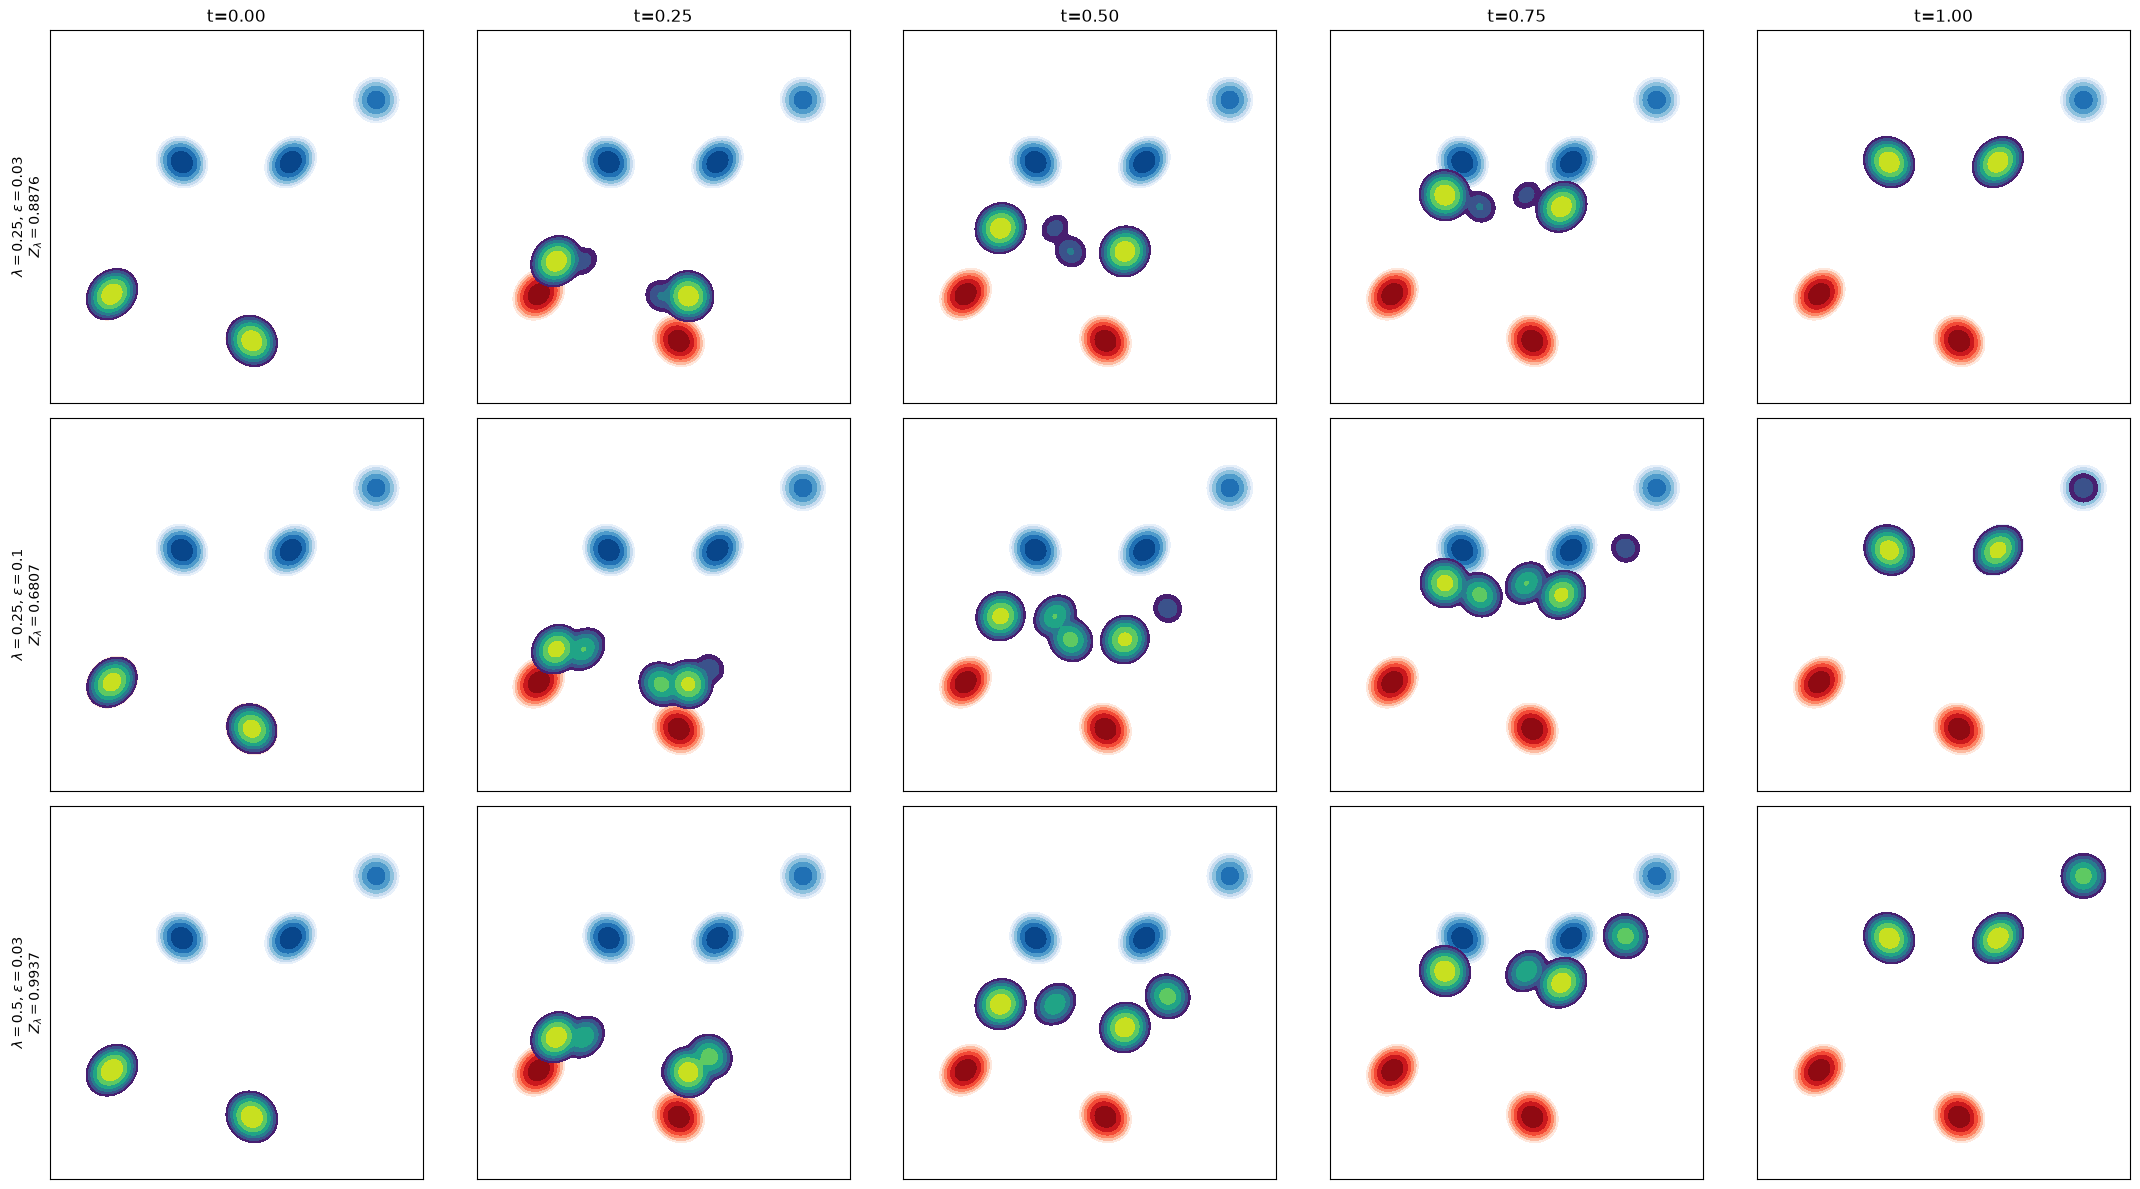

In [5]:
figure4, axes = plt.subplots(3, 5, figsize=(22, 12))
for row, solve in enumerate(row_solves):
    for column, t in enumerate(times):
        axis = axes[row, column]
        draw_density(axis, density_source, levels_source, "Reds")
        draw_density(axis, density_target, levels_target, "Blues")
        draw_density(axis, panels[(row, column)], levels_interpolation, "viridis")
        axis.set_xlim(-12, 12)
        axis.set_ylim(-12, 12)
        if row == 0:
            axis.set_title(f"t={t:.2f}")
        if column == 0:
            axis.set_ylabel(
                rf"$\lambda={solve['paper_lambda']}$, "
                rf"$\varepsilon={solve['epsilon']}$"
                "\n"
                rf"$Z_\lambda={solve['matched_mass']:.4f}$"
            )
        axis.set_xticks([])
        axis.set_yticks([])
figure4.tight_layout()
figure4_path = OUTPUT_DIR / "figure4.pdf"
figure4.savefig(figure4_path, format="pdf", bbox_inches="tight")
write_figure_sidecar(
    METADATA_DIR / "figure4.json",
    figure=4,
    outputs=[figure4_path],
    panels=panel_records,
    inputs={
        "source_weights": source.weights,
        "source_means": source.comp_mean,
        "source_covariances": source.comp_cov,
        "target_weights": target.weights,
        "target_means": target.comp_mean,
        "target_covariances": target.comp_cov,
        "density_grid": {"limits": [-12, 12], "points_per_axis": 400},
        "shared_density_levels": levels_interpolation,
    },
    seeds={"sampling": None, "fit": None},
    notes="Equation (4.17) closed form; (4.18) sub-probability mass.",
)
plt.show()
